# Load Prediction Model Evaluation 📈

This notebook evaluates the performance of the trained `LoadPredictor` DNN and visualizes the stochastic scenarios generated by the ML service.

In [15]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import sys
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Add ml_service/src to path
sys.path.append(os.path.join(os.getcwd(), "..", "ml_service", "src"))

from model.predictor import load_model
from external_data.load_sensor import LoadSensor

sns.set_theme(style="whitegrid")

## 1. Load Data and Artifacts

In [16]:
DATA_PATH = "../ml_service/data/training_data.parquet"
df = pd.read_parquet(DATA_PATH)

# Use the refactored training function from the official pipeline
model, scaler = train_model(DATA_PATH)

print(f"✅ Loaded {len(df)} records and trained model using ml_pipeline.train_model.")
df.head()

NameError: name 'StandardScaler' is not defined

## 2. Evaluation on Test Set

We take a small slice (last 7 days of 2024) to see how the model performs on "unseen" temporal patterns.

In [ ]:
# Define features
feature_cols = ['solar_kw', 'temp_c', 'hour', 'dayofweek', 'month']
target_col = 'load_kw'

# Take a test slice (last week of 2024)
test_df = df.tail(24 * 7).copy()

X = test_df[feature_cols].values.astype(np.float32)
y_true = test_df[target_col].values

# Scale and Predict
X_scaled = scaler.transform(X)
X_tensor = torch.from_numpy(X_scaled)

with torch.no_grad():
    y_pred = model(X_tensor).numpy().flatten()

test_df['pred_load_kw'] = y_pred

# Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"📊 Metrics for last 7 days:")
print(f"- MAE:  {mae:.4f} kW")
print(f"- RMSE: {rmse:.4f} kW")
print(f"- R2:   {r2:.4f}")

📊 Metrics for last 7 days:
- MAE:  0.3085 kW
- RMSE: 0.3757 kW
- R2:   0.9228


## 3. Visualizing Results

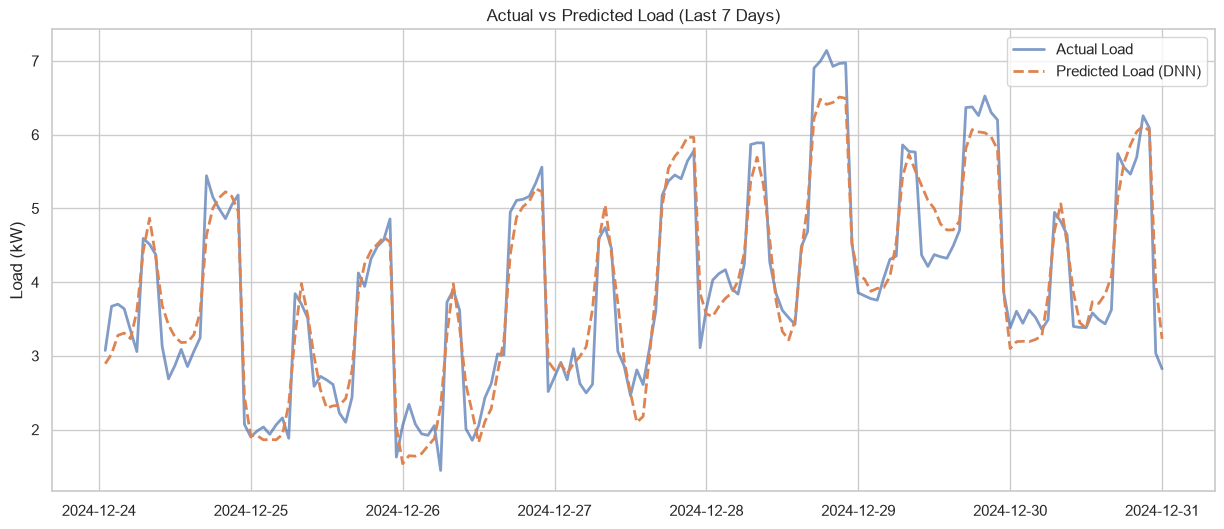

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(test_df.index, test_df['load_kw'], label="Actual Load", alpha=0.7, lw=2)
plt.plot(test_df.index, test_df['pred_load_kw'], label="Predicted Load (DNN)", ls="--", lw=2)
plt.title("Actual vs Predicted Load (Last 7 Days)")
plt.ylabel("Load (kW)")
plt.legend()
plt.show()

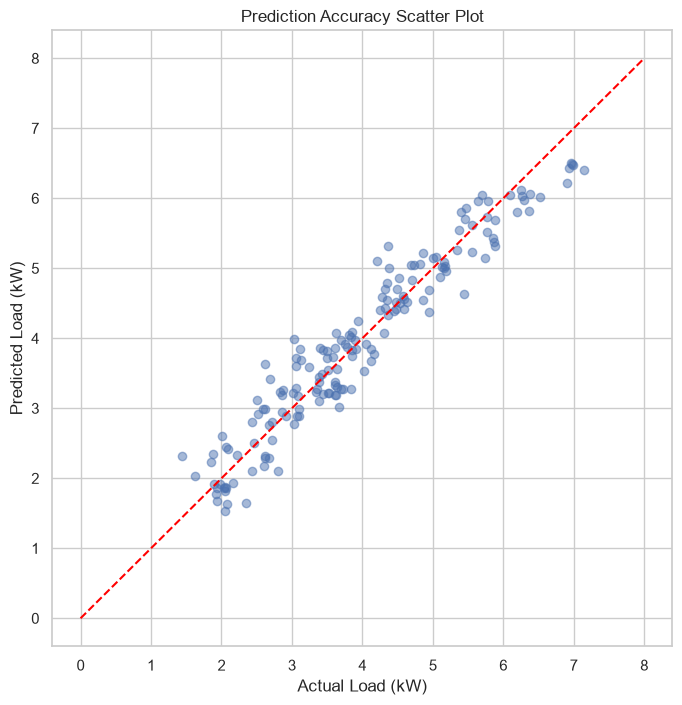

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([0, 8], [0, 8], color='red', linestyle='--')
plt.xlabel("Actual Load (kW)")
plt.ylabel("Predicted Load (kW)")
plt.title("Prediction Accuracy Scatter Plot")
plt.show()

## 4. Stochastic Scenario Generation

The optimization service uses multiple scenarios to build a robust plan. Let's see how these look.

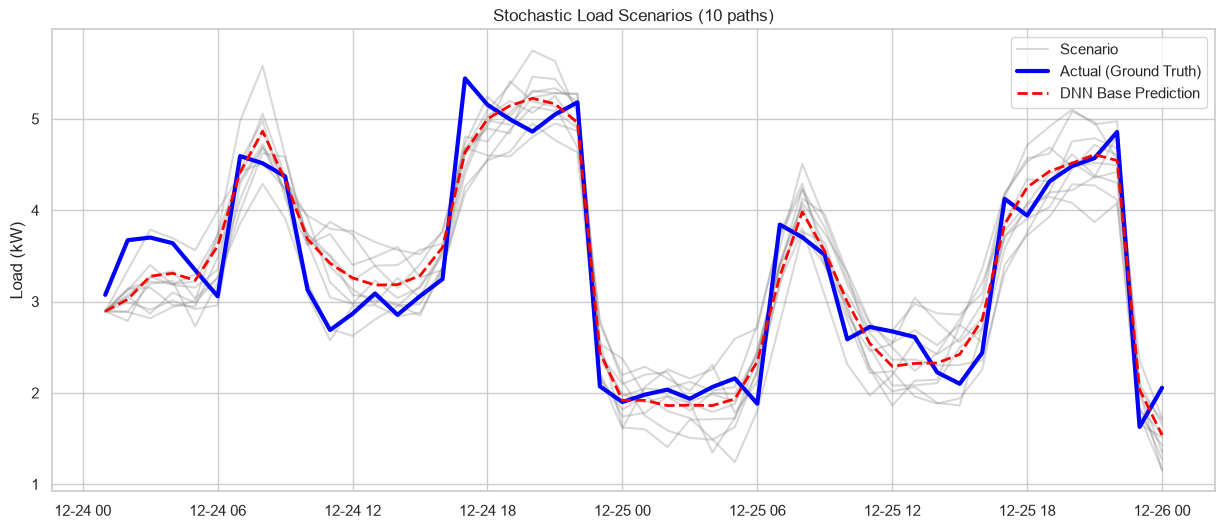

In [ ]:
# Generate 10 scenarios for the first 48 hours of the test set
n_hours = 48
n_scenarios = 10
base_forecast = y_pred[:n_hours]
times = test_df.index[:n_hours]

plt.figure(figsize=(15, 6))

for i in range(n_scenarios):
    noise = DataGenerator.generate_ar1_noise(n_hours)
    scenario = np.maximum(0.1, base_forecast + noise)
    plt.plot(times, scenario, color='gray', alpha=0.3, label="Scenario" if i == 0 else "")

plt.plot(times, test_df['load_kw'][:n_hours], color='blue', lw=3, label="Actual (Ground Truth)")
plt.plot(times, base_forecast, color='red', ls="--", lw=2, label="DNN Base Prediction")

plt.title(f"Stochastic Load Scenarios ({n_scenarios} paths)")
plt.ylabel("Load (kW)")
plt.legend()
plt.show()